# Agentic

In [3]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

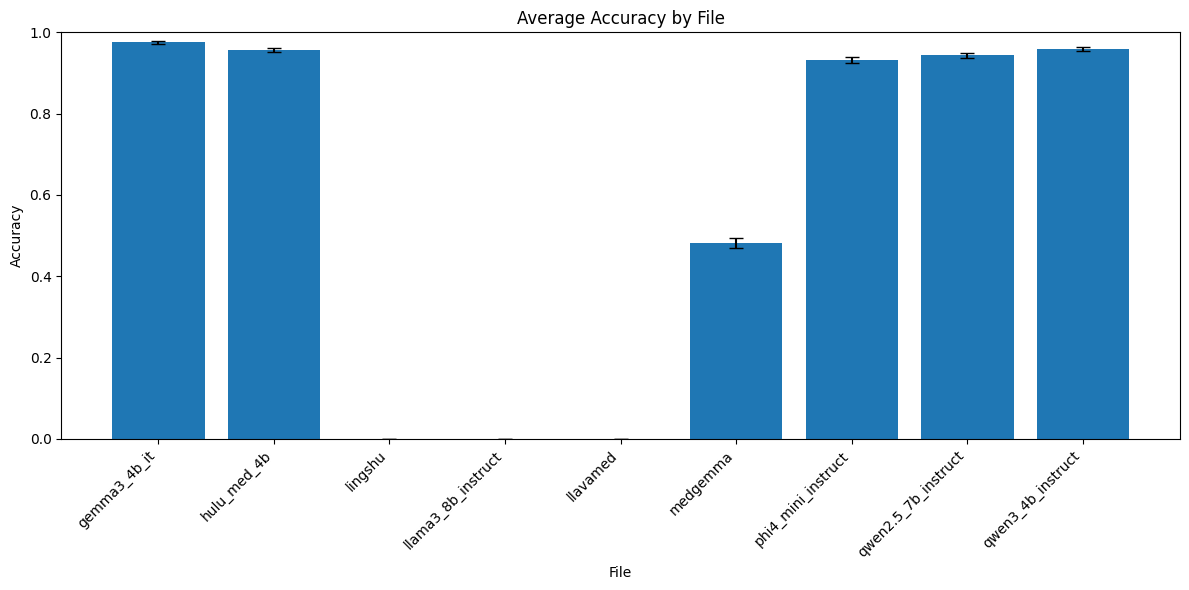

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

input_dir = "output/phase_2/agentic_filtering"

file_names = []
acc_means = []
acc_errs = []

use_sem = True   # True: standard error, False: standard deviation

for file in sorted(os.listdir(input_dir)):
    if not file.endswith(".jsonl"):
        continue

    file_path = os.path.join(input_dir, file)

    with open(file_path, "r") as f:
        data = [json.loads(line) for line in f]

    # lấy correct của toàn bộ sample trong file
    corrects = np.array([1 if row["correct"] else 0 for row in data], dtype=float)

    acc = corrects.mean()

    if use_sem:
        err = corrects.std(ddof=1) / np.sqrt(len(corrects))   # standard error
    else:
        err = corrects.std(ddof=1)                            # standard deviation

    file_names.append(os.path.splitext(file)[0])
    acc_means.append(acc)
    acc_errs.append(err)

# plot
plt.figure(figsize=(12, 6))
plt.bar(file_names, acc_means, yerr=acc_errs, capsize=5)
plt.ylabel("Accuracy")
plt.xlabel("File")
plt.title("Average Accuracy by File")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
import os
import json
import numpy as np
import pandas as pd
from collections import defaultdict

input_dir = "output/phase_2/agentic_filtering"

rows = []

for file in sorted(os.listdir(input_dir)):
    if not file.endswith(".jsonl"):
        continue

    file_path = os.path.join(input_dir, file)

    with open(file_path, "r") as f:
        data = [json.loads(line) for line in f]

    grouped = defaultdict(list)
    for row in data:
        key = (row["emotion"], row["conv_mode"])
        grouped[key].append(1 if row["correct"] else 0)

    group_accs = np.array([np.mean(v) for v in grouped.values()], dtype=float)

    mean_acc = group_accs.mean()
    std_acc = group_accs.std(ddof=1) if len(group_accs) > 1 else 0.0
    sem_acc = std_acc / np.sqrt(len(group_accs)) if len(group_accs) > 1 else 0.0

    rows.append({
        "model": os.path.splitext(file)[0],
        "n_groups": len(group_accs),
        "mean_accuracy": mean_acc,
        "std": std_acc,
        "sem": sem_acc,
    })

df = pd.DataFrame(rows)
df = df.sort_values("mean_accuracy", ascending=False).reset_index(drop=True)

# format đẹp hơn để nhìn
df["mean_accuracy"] = df["mean_accuracy"].map(lambda x: f"{x:.4f}")
df["std"] = df["std"].map(lambda x: f"{x:.4f}")
df["sem"] = df["sem"].map(lambda x: f"{x:.4f}")

print(df.to_string(index=False))

              model  n_groups mean_accuracy    std    sem
       gemma3_4b_it        32        0.9750 0.0197 0.0035
  qwen3_4b_instruct        32        0.9600 0.0000 0.0000
        hulu_med_4b        32        0.9563 0.0148 0.0026
qwen2.5_7b_instruct        32        0.9431 0.1188 0.0210
 phi4_mini_instruct        32        0.9319 0.0577 0.0102
           medgemma        32        0.4825 0.2680 0.0474
           llavamed        32        0.0000 0.0000 0.0000
            lingshu        32        0.0000 0.0000 0.0000
 llama3_8b_instruct        32        0.0000 0.0000 0.0000


# Contrastive

In [9]:
for folder in os.listdir("output/phase_2/contrastive_decoding"):
    print(folder, len(os.listdir(os.path.join("output/phase_2/contrastive_decoding", folder))))

Hulu-Med 34
MedGemma 34
Lingshu 34
LLaVA-Med 34


In [13]:
for folder in os.listdir("output/phase_2/contrastive_decoding"):
    print(folder, len([f for f in os.listdir(os.path.join("output/phase_2", folder)) if f.endswith("closed.jsonl") and 'single' in f and 'eval_' not in f]))

Hulu-Med 34
MedGemma 34
Lingshu 34
LLaVA-Med 34


In [39]:
from emotion_prompts import USER_PROMPTS

num_user_prompts = len(USER_PROMPTS)
prompt_names = USER_PROMPTS.keys()

dataset_mapping = {
    "slake": "SLAKE",
    "vqarad": "vqa-rad",
}

def normalize_dataset_name_in_filename(filename, dataset_name_map):
    normalized = filename
    for old_name, new_name in dataset_name_map.items():
        normalized = normalized.replace(old_name, new_name)
    return normalized

def file_matches_prompt_and_dataset(filename, prompt_name, dataset_name):
    return f"_{dataset_name}_" in filename and f"_{prompt_name}" in filename

In [40]:
for folder in os.listdir("output/phase_2/contrastive_decoding"):
    original = [
        f for f in os.listdir(os.path.join("output/phase_2", folder))
        if f.endswith("closed.jsonl") and "single" in f and "eval_" not in f
    ]
    black = os.listdir(os.path.join("output/phase_2/contrastive_decoding", folder))

    original_norm = [normalize_dataset_name_in_filename(f, dataset_mapping) for f in original]
    black_norm = [normalize_dataset_name_in_filename(f, dataset_mapping) for f in black]

    for prompt_name in prompt_names:
        for dataset_name in dataset_mapping.values():
            matched_original = [f for f in original_norm if file_matches_prompt_and_dataset(f, prompt_name, dataset_name)]
            matched_black = [f for f in black_norm if file_matches_prompt_and_dataset(f, prompt_name, dataset_name)]

            if matched_original:
                print(f"\nfolder: {folder} | prompt: {prompt_name} | dataset: {dataset_name}")
                print("original:", matched_original)
                print("black:", matched_black)


folder: Hulu-Med | prompt: default | dataset: SLAKE
original: ['hulumed_SLAKE_single_default_closed.jsonl']
black: ['hulumed_SLAKE_single_default_closed.jsonl']

folder: Hulu-Med | prompt: default | dataset: vqa-rad
original: ['hulumed_vqa-rad_single_default_closed.jsonl']
black: ['hulumed_vqa-rad_single_default_closed.jsonl']

folder: Hulu-Med | prompt: direct_patient_neutral | dataset: SLAKE
original: ['hulumed_SLAKE_single_direct_patient_neutral_closed.jsonl']
black: ['hulumed_SLAKE_single_direct_patient_neutral_closed.jsonl']

folder: Hulu-Med | prompt: direct_patient_neutral | dataset: vqa-rad
original: ['hulumed_vqa-rad_single_direct_patient_neutral_closed.jsonl']
black: ['hulumed_vqa-rad_single_direct_patient_neutral_closed.jsonl']

folder: Hulu-Med | prompt: direct_patient_fear_anxiety | dataset: SLAKE
original: ['hulumed_SLAKE_single_direct_patient_fear_anxiety_closed.jsonl']
black: ['hulumed_SLAKE_single_direct_patient_fear_anxiety_closed.jsonl']

folder: Hulu-Med | prompt: 

In [26]:
import os
import json
import numpy as np
import pandas as pd

ALPHAS = [0, 0.1, 0.2, 0.5, 1.0]

YES_KEY = "yes_prob"
NO_KEY = "no_prob"
ANSWER_KEY = "answer"

dataset_mapping = {
    "slake": "SLAKE",
    "vqarad": "vqa-rad",
}

In [28]:
def load_jsonl(path):
    with open(path, "r") as f:
        return [json.loads(line) for line in f]

def normalize_dataset_name_in_filename(filename, dataset_name_map):
    out = filename
    for old_name, new_name in dataset_name_map.items():
        out = out.replace(old_name, new_name)
    return out

def get_prediction_from_scores(score_yes, score_no):
    return "Yes" if score_yes > score_no else "No"

def get_prediction_from_row(row, yes_key=YES_KEY, no_key=NO_KEY):
    return get_prediction_from_scores(float(row[yes_key]), float(row[no_key]))

def normalize_answer(ans):
    ans = str(ans).strip().lower()
    if ans == "yes":
        return "Yes"
    if ans == "no":
        return "No"
    raise ValueError(f"Unexpected answer value: {ans}")

def contrastive_decode_row(ori_row, black_row, a,
                           yes_key=YES_KEY, no_key=NO_KEY):
    yes_ori = float(ori_row[yes_key])
    no_ori = float(ori_row[no_key])

    yes_black = float(black_row[yes_key])
    no_black = float(black_row[no_key])

    score_yes_cd = (1 + a) * yes_ori - a * yes_black
    score_no_cd  = (1 + a) * no_ori  - a * no_black

    pred_cd = get_prediction_from_scores(score_yes_cd, score_no_cd)

    return {
        "score_yes_cd": score_yes_cd,
        "score_no_cd": score_no_cd,
        "pred_cd": pred_cd,
        "margin_cd": abs(score_yes_cd - score_no_cd),
    }
    
from emotion_prompts import USER_PROMPTS

prompt_names = list(USER_PROMPTS.keys())

def extract_emotion_from_filename(filename, prompt_names):
    for prompt_name in prompt_names:
        if f"_{prompt_name}_" in filename:
            return prompt_name
    raise ValueError(f"Cannot extract emotion from filename: {filename}")

In [30]:
def build_cd_dataframe(original_data, black_data, emotion, alphas=ALPHAS):
    assert len(original_data) == len(black_data), "original và black khác số dòng"

    rows = []

    for idx, (ori_row, black_row) in enumerate(zip(original_data, black_data)):
        gt_label = normalize_answer(ori_row[ANSWER_KEY])

        pred_ori = get_prediction_from_row(ori_row)
        pred_black = get_prediction_from_row(black_row)

        for a in alphas:
            cd_out = contrastive_decode_row(ori_row, black_row, a)
            correct_cd = (cd_out["pred_cd"] == gt_label)

            rows.append({
                "sample_idx": idx,
                "emotion": emotion,
                "alpha": a,

                "answer": gt_label,

                "pred_ori": pred_ori,
                "pred_black": pred_black,
                "pred_cd": cd_out["pred_cd"],

                "correct_ori": pred_ori == gt_label,
                "correct_black": pred_black == gt_label,
                "correct_cd": correct_cd,

                "score_yes_ori": float(ori_row[YES_KEY]),
                "score_no_ori": float(ori_row[NO_KEY]),
                "score_yes_black": float(black_row[YES_KEY]),
                "score_no_black": float(black_row[NO_KEY]),

                "score_yes_cd": cd_out["score_yes_cd"],
                "score_no_cd": cd_out["score_no_cd"],
                "margin_cd": cd_out["margin_cd"],
            })

    return pd.DataFrame(rows)

def summarize_overall(df):
    rows = []
    for a, sub in df.groupby("alpha"):
        rows.append({
            "alpha": a,
            "n": len(sub),
            "accuracy": sub["correct_cd"].mean(),
            "mean_margin": sub["margin_cd"].mean(),
            "pred_yes_rate": (sub["pred_cd"] == "Yes").mean(),
        })
    return pd.DataFrame(rows).sort_values("alpha")

def summarize_by_emotion(df):
    rows = []
    for (a, emotion), sub in df.groupby(["alpha", "emotion"]):
        rows.append({
            "alpha": a,
            "emotion": emotion,
            "n": len(sub),
            "accuracy": sub["correct_cd"].mean(),
            "mean_margin": sub["margin_cd"].mean(),
            "pred_yes_rate": (sub["pred_cd"] == "Yes").mean(),
        })
    return pd.DataFrame(rows).sort_values(["alpha", "emotion"])

def summarize_emotion_consistency(emotion_summary_df):
    rows = []
    for a, sub in emotion_summary_df.groupby("alpha"):
        accs = sub["accuracy"].values
        rows.append({
            "alpha": a,
            "emotion_acc_mean": np.mean(accs),
            "emotion_acc_std": np.std(accs, ddof=1) if len(accs) > 1 else 0.0,
            "emotion_acc_min": np.min(accs),
            "emotion_acc_max": np.max(accs),
            "emotion_acc_range": np.max(accs) - np.min(accs),
        })
    return pd.DataFrame(rows).sort_values("alpha")

def flip_analysis(df):
    base = df[df["alpha"] == 0][["sample_idx", "emotion", "correct_cd", "pred_cd"]].copy()
    base = base.rename(columns={
        "correct_cd": "correct_a0",
        "pred_cd": "pred_a0"
    })

    merged = df.merge(base, on=["sample_idx", "emotion"], how="left")

    rows = []
    for a, sub in merged.groupby("alpha"):
        changed = (sub["pred_cd"] != sub["pred_a0"]).sum()
        wrong_to_right = ((sub["correct_a0"] == False) & (sub["correct_cd"] == True)).sum()
        right_to_wrong = ((sub["correct_a0"] == True) & (sub["correct_cd"] == False)).sum()

        rows.append({
            "alpha": a,
            "n_changed_predictions": changed,
            "wrong_to_right": wrong_to_right,
            "right_to_wrong": right_to_wrong,
            "net_gain": wrong_to_right - right_to_wrong,
        })

    return pd.DataFrame(rows).sort_values("alpha")

In [33]:
ori_path = "output/phase_2/Hulu-Med/hulumed_SLAKE_single_default_closed.jsonl"
black_path = "output/phase_2/contrastive_decoding/Hulu-Med/hulumed_SLAKE_single_default_closed.jsonl"

emotion = extract_emotion_from_filename(os.path.basename(ori_path), prompt_names)

original_data = load_jsonl(ori_path)
black_data = load_jsonl(black_path)

df_cd = build_cd_dataframe(original_data, black_data, emotion=emotion, alphas=ALPHAS)

overall_summary = summarize_overall(df_cd)
emotion_summary = summarize_by_emotion(df_cd)
consistency_summary = summarize_emotion_consistency(emotion_summary)
flip_summary = flip_analysis(df_cd)

print("=== Overall ===")
print(overall_summary)

print("\n=== By emotion ===")
print(emotion_summary)

print("\n=== Emotion consistency ===")
print(consistency_summary)

print("\n=== Flip analysis ===")
print(flip_summary)

=== Overall ===
   alpha    n  accuracy  mean_margin  pred_yes_rate
0    0.0  355  0.878873     0.663310       0.490141
1    0.1  355  0.881690     0.734890       0.509859
2    0.2  355  0.884507     0.807790       0.518310
3    0.5  355  0.867606     1.035050       0.552113
4    1.0  355  0.861972     1.432234       0.585915

=== By emotion ===
   alpha  emotion    n  accuracy  mean_margin  pred_yes_rate
0    0.0  default  355  0.878873     0.663310       0.490141
1    0.1  default  355  0.881690     0.734890       0.509859
2    0.2  default  355  0.884507     0.807790       0.518310
3    0.5  default  355  0.867606     1.035050       0.552113
4    1.0  default  355  0.861972     1.432234       0.585915

=== Emotion consistency ===
   alpha  emotion_acc_mean  emotion_acc_std  emotion_acc_min  emotion_acc_max  \
0    0.0          0.878873              0.0         0.878873         0.878873   
1    0.1          0.881690              0.0         0.881690         0.881690   
2    0.2      

In [34]:
def run_one_pair(ori_path, black_path, model_name, dataset_name):
    emotion = extract_emotion_from_filename(os.path.basename(ori_path), prompt_names)

    original_data = load_jsonl(ori_path)
    black_data = load_jsonl(black_path)

    df = build_cd_dataframe(original_data, black_data, emotion=emotion, alphas=ALPHAS)
    df["model"] = model_name
    df["dataset"] = dataset_name
    return df

In [42]:
all_dfs = []

for folder in os.listdir("output/phase_2/contrastive_decoding"):
    original = [
        f for f in os.listdir(os.path.join("output/phase_2", folder))
        if f.endswith("closed.jsonl") and "single" in f and "eval_" not in f
    ]
    black = [
        f for f in os.listdir(os.path.join("output/phase_2/contrastive_decoding", folder))
        if f.endswith(".jsonl")
    ]

    original_map = {
        f: normalize_dataset_name_in_filename(f, dataset_mapping)
        for f in original
    }
    black_map = {
        f: normalize_dataset_name_in_filename(f, dataset_mapping)
        for f in black
    }

    for prompt_name in prompt_names:
        for dataset_name in dict.fromkeys(dataset_mapping.values()):
            matched_original = [
                orig_file
                for orig_file, norm_file in original_map.items()
                if file_matches_prompt_and_dataset(norm_file, prompt_name, dataset_name)
            ]
            matched_black = [
                black_file
                for black_file, norm_file in black_map.items()
                if file_matches_prompt_and_dataset(norm_file, prompt_name, dataset_name)
            ]

            if len(matched_original) == 0 or len(matched_black) == 0:
                continue
            
            try:
                all_dfs.append(
                    run_one_pair(
                        ori_path=os.path.join("output/phase_2", folder, matched_original[0]),
                        black_path=os.path.join("output/phase_2/contrastive_decoding", folder, matched_black[0]),
                        model_name=folder,
                        dataset_name=dataset_name,
                    )
                )
            except Exception as e:
                pass

full_df = pd.concat(all_dfs, ignore_index=True)

In [43]:
model_dataset_alpha_summary = (
    full_df.groupby(["model", "dataset", "alpha"])
    .agg(
        n=("correct_cd", "size"),
        accuracy=("correct_cd", "mean"),
        mean_margin=("margin_cd", "mean"),
        pred_yes_rate=("pred_cd", lambda s: (s == "Yes").mean()),
    )
    .reset_index()
    .sort_values(["model", "dataset", "alpha"])
)

print(model_dataset_alpha_summary)

        model  dataset  alpha     n  accuracy  mean_margin  pred_yes_rate
0    Hulu-Med    SLAKE    0.0  6035  0.788401     0.544458       0.408285
1    Hulu-Med    SLAKE    0.1  6035  0.800994     0.592048       0.449710
2    Hulu-Med    SLAKE    0.2  6035  0.803480     0.642696       0.468766
3    Hulu-Med    SLAKE    0.5  6035  0.805634     0.805081       0.512013
4    Hulu-Med    SLAKE    1.0  6035  0.804143     1.098448       0.558906
5    Hulu-Med  vqa-rad    0.0  4267  0.698149     0.522408       0.247481
6    Hulu-Med  vqa-rad    0.1  4267  0.713382     0.539443       0.282869
7    Hulu-Med  vqa-rad    0.2  4267  0.718303     0.558499       0.299508
8    Hulu-Med  vqa-rad    0.5  4267  0.731896     0.626516       0.346379
9    Hulu-Med  vqa-rad    1.0  4267  0.745020     0.762926       0.404968
10  LLaVA-Med    SLAKE    0.0  6035  0.607954     0.589147       0.790555
11  LLaVA-Med    SLAKE    0.1  6035  0.612925     0.611379       0.789229
12  LLaVA-Med    SLAKE    0.2  6035  0

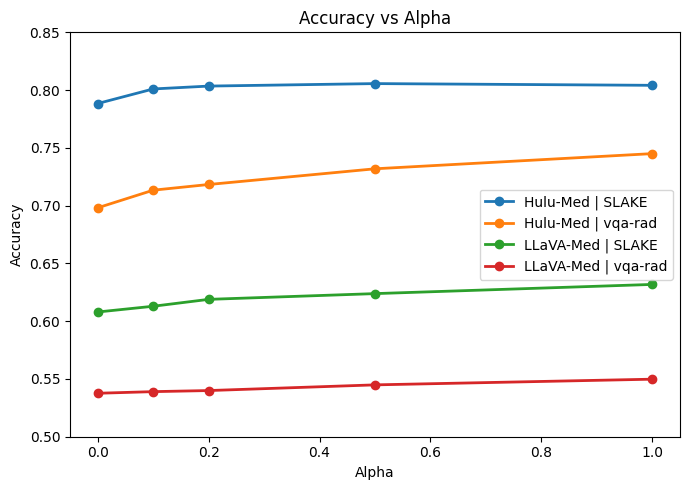

In [77]:
plot_df = model_dataset_alpha_summary[
    model_dataset_alpha_summary["model"].isin(["Hulu-Med", "LLaVA-Med"])
].copy()

plot_df["label"] = plot_df["model"] + " | " + plot_df["dataset"]

plt.figure(figsize=(7, 5))

for label, sub in plot_df.groupby("label"):
    sub = sub.sort_values("alpha")
    plt.plot(
        sub["alpha"],
        sub["accuracy"],
        marker="o",
        linewidth=2,
        label=label
    )

plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha")
plt.ylim(0.5, 0.85)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
emotion_level_summary = (
    full_df.groupby(["model", "dataset", "alpha", "emotion"])
    .agg(accuracy=("correct_cd", "mean"))
    .reset_index()
)

consistency_summary = (
    emotion_level_summary.groupby(["model", "dataset", "alpha"])
    .agg(
        emotion_acc_mean=("accuracy", "mean"),
        emotion_acc_std=("accuracy", "std"),
        emotion_acc_min=("accuracy", "min"),
        emotion_acc_max=("accuracy", "max"),
    )
    .reset_index()
)

consistency_summary["emotion_acc_range"] = (
    consistency_summary["emotion_acc_max"] - consistency_summary["emotion_acc_min"]
)

print(consistency_summary)

        model  dataset  alpha  emotion_acc_mean  emotion_acc_std  \
0    Hulu-Med    SLAKE    0.0          0.788401         0.042719   
1    Hulu-Med    SLAKE    0.1          0.800994         0.037263   
2    Hulu-Med    SLAKE    0.2          0.803480         0.036910   
3    Hulu-Med    SLAKE    0.5          0.805634         0.034485   
4    Hulu-Med    SLAKE    1.0          0.804143         0.034944   
5    Hulu-Med  vqa-rad    0.0          0.698149         0.069643   
6    Hulu-Med  vqa-rad    0.1          0.713382         0.058731   
7    Hulu-Med  vqa-rad    0.2          0.718303         0.056620   
8    Hulu-Med  vqa-rad    0.5          0.731896         0.046649   
9    Hulu-Med  vqa-rad    1.0          0.745020         0.037268   
10  LLaVA-Med    SLAKE    0.0          0.607954         0.023552   
11  LLaVA-Med    SLAKE    0.1          0.612925         0.020581   
12  LLaVA-Med    SLAKE    0.2          0.618890         0.020185   
13  LLaVA-Med    SLAKE    0.5          0.623861 

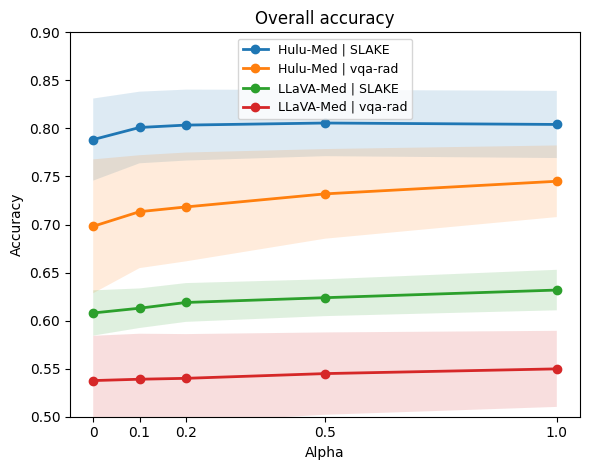

In [83]:
# Block 1: left panel only
# Overall accuracy + std band across emotions (4 lines)

models_to_plot = ["Hulu-Med", "LLaVA-Med"]
alpha_ticks = [0, 0.1, 0.2, 0.5, 1.0]

overall_df = model_dataset_alpha_summary[
    model_dataset_alpha_summary["model"].isin(models_to_plot)
].copy()

emo_band_df = emotion_level_summary[
    emotion_level_summary["model"].isin(models_to_plot)
].copy()

emo_band_summary = (
    emo_band_df.groupby(["model", "dataset", "alpha"])
    .agg(std_acc=("accuracy", "std"))
    .reset_index()
)

left_df = overall_df.merge(
    emo_band_summary,
    on=["model", "dataset", "alpha"],
    how="left"
)
left_df["label"] = left_df["model"] + " | " + left_df["dataset"]

plt.figure(figsize=(6, 4.8))

for label, sub in left_df.groupby("label"):
    sub = sub.sort_values("alpha")
    plt.plot(
        sub["alpha"],
        sub["accuracy"],
        marker="o",
        linewidth=2,
        label=label
    )
    plt.fill_between(
        sub["alpha"].values,
        (sub["accuracy"] - sub["std_acc"]).values,
        (sub["accuracy"] + sub["std_acc"]).values,
        alpha=0.15
    )

plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Overall accuracy")
plt.ylim(0.50, 0.90)
plt.xticks(alpha_ticks, ["0", "0.1", "0.2", "0.5", "1.0"])
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

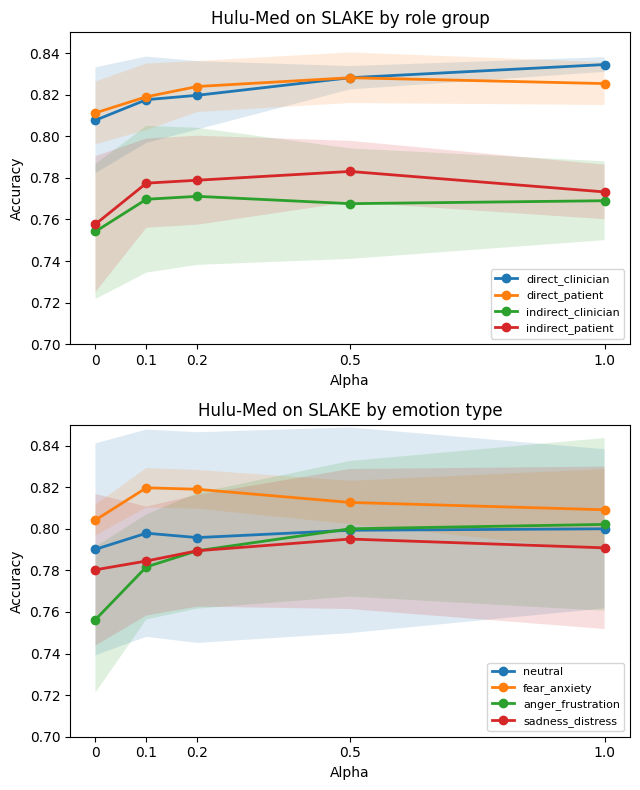

In [85]:
# Block 2: middle + right as 2x1
# Top    : grouped by direct/indirect + role, mean ± std band
# Bottom : grouped by emotion type, mean ± std band
# Hulu-Med on SLAKE

alpha_ticks = [0, 0.1, 0.2, 0.5, 1.0]

sub = emotion_level_summary[
    (emotion_level_summary["model"] == "Hulu-Med") &
    (emotion_level_summary["dataset"] == "SLAKE") &
    (emotion_level_summary["emotion"] != "default")
].copy()

def to_role_group(emotion):
    parts = emotion.split("_")
    return f"{parts[0]}_{parts[1]}"

def to_emotion_group(emotion):
    parts = emotion.split("_")
    return "_".join(parts[2:])

sub["role_group"] = sub["emotion"].apply(to_role_group)
sub["emotion_group"] = sub["emotion"].apply(to_emotion_group)

fig, axes = plt.subplots(2, 1, figsize=(6.5, 8))

# Top: role group
mid_df = (
    sub.groupby(["role_group", "alpha"])
    .agg(
        mean_acc=("accuracy", "mean"),
        std_acc=("accuracy", "std"),
    )
    .reset_index()
)

for group_name, group_sub in mid_df.groupby("role_group"):
    group_sub = group_sub.sort_values("alpha")
    axes[0].plot(
        group_sub["alpha"],
        group_sub["mean_acc"],
        marker="o",
        linewidth=2,
        label=group_name
    )
    axes[0].fill_between(
        group_sub["alpha"].values,
        (group_sub["mean_acc"] - group_sub["std_acc"]).values,
        (group_sub["mean_acc"] + group_sub["std_acc"]).values,
        alpha=0.15
    )

axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Hulu-Med on SLAKE by role group")
axes[0].set_ylim(0.70, 0.85)
axes[0].set_xticks(alpha_ticks)
axes[0].set_xticklabels(["0", "0.1", "0.2", "0.5", "1.0"])
axes[0].legend(fontsize=8)

# Bottom: emotion type
right_df = (
    sub.groupby(["emotion_group", "alpha"])
    .agg(
        mean_acc=("accuracy", "mean"),
        std_acc=("accuracy", "std"),
    )
    .reset_index()
)

emotion_order = ["neutral", "fear_anxiety", "anger_frustration", "sadness_distress"]
right_df["emotion_group"] = pd.Categorical(
    right_df["emotion_group"],
    categories=emotion_order,
    ordered=True
)
right_df = right_df.sort_values(["emotion_group", "alpha"])

for group_name, group_sub in right_df.groupby("emotion_group", observed=False):
    group_sub = group_sub.sort_values("alpha")
    axes[1].plot(
        group_sub["alpha"],
        group_sub["mean_acc"],
        marker="o",
        linewidth=2,
        label=group_name
    )
    axes[1].fill_between(
        group_sub["alpha"].values,
        (group_sub["mean_acc"] - group_sub["std_acc"]).values,
        (group_sub["mean_acc"] + group_sub["std_acc"]).values,
        alpha=0.15
    )

axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Hulu-Med on SLAKE by emotion type")
axes[1].set_ylim(0.70, 0.85)
axes[1].set_xticks(alpha_ticks)
axes[1].set_xticklabels(["0", "0.1", "0.2", "0.5", "1.0"])
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
for folder in os.listdir("output/phase_2/contrastive_decoding"):
    original = [
        f for f in os.listdir(os.path.join("output/phase_2", folder))
        if f.endswith("closed.jsonl") and "single" in f and "eval_" not in f
    ]
    black = os.listdir(os.path.join("output/phase_2/contrastive_decoding", folder))

    original_norm = [normalize_dataset_name_in_filename(f, dataset_mapping) for f in original]
    black_norm = [normalize_dataset_name_in_filename(f, dataset_mapping) for f in black]

    for prompt_name in prompt_names:
        for dataset_name in dataset_mapping.values():
            matched_original = [f for f in original_norm if file_matches_prompt_and_dataset(f, prompt_name, dataset_name)]
            matched_black = [f for f in black_norm if file_matches_prompt_and_dataset(f, prompt_name, dataset_name)]

            if matched_original:
                print(f"\nfolder: {folder} | prompt: {prompt_name} | dataset: {dataset_name}")
                print("original:", matched_original)
                print("black:", matched_black)


folder: Hulu-Med | prompt: default | dataset: SLAKE
original: ['hulumed_SLAKE_single_default_closed.jsonl']
black: ['hulumed_SLAKE_single_default_closed.jsonl']

folder: Hulu-Med | prompt: default | dataset: vqa-rad
original: ['hulumed_vqa-rad_single_default_closed.jsonl']
black: ['hulumed_vqa-rad_single_default_closed.jsonl']

folder: Hulu-Med | prompt: direct_patient_neutral | dataset: SLAKE
original: ['hulumed_SLAKE_single_direct_patient_neutral_closed.jsonl']
black: ['hulumed_SLAKE_single_direct_patient_neutral_closed.jsonl']

folder: Hulu-Med | prompt: direct_patient_neutral | dataset: vqa-rad
original: ['hulumed_vqa-rad_single_direct_patient_neutral_closed.jsonl']
black: ['hulumed_vqa-rad_single_direct_patient_neutral_closed.jsonl']

folder: Hulu-Med | prompt: direct_patient_fear_anxiety | dataset: SLAKE
original: ['hulumed_SLAKE_single_direct_patient_fear_anxiety_closed.jsonl']
black: ['hulumed_SLAKE_single_direct_patient_fear_anxiety_closed.jsonl']

folder: Hulu-Med | prompt: 

In [54]:
default_df = (
    full_df[full_df["emotion"] == "default"][["model", "dataset", "alpha", "sample_idx", "pred_cd"]]
    .rename(columns={"pred_cd": "pred_cd_default"})
)

compare_df = full_df.merge(
    default_df,
    on=["model", "dataset", "alpha", "sample_idx"],
    how="left"
)

compare_df["agree_with_default_emotion"] = (
    compare_df["pred_cd"] == compare_df["pred_cd_default"]
)

In [57]:
agreement_to_default = (
    compare_df.groupby(["model", "dataset", "emotion", "alpha"])
    .agg(
        n=("agree_with_default_emotion", "size"),
        agreement_to_default=("agree_with_default_emotion", "mean"),
    )
    .reset_index()
    .sort_values(["model", "dataset", "emotion", "alpha"])
)

agreement_to_default["flip_from_default"] = 1 - agreement_to_default["agreement_to_default"]
agreement_to_default[agreement_to_default["emotion"] != "default"]

,model,dataset,emotion,alpha,n,agreement_to_default,flip_from_default
5,Hulu-Med,SLAKE,direct_clinician_anger_frustration,0.0,355,0.788732,0.211268
6,Hulu-Med,SLAKE,direct_clinician_anger_frustration,0.1,355,0.808451,0.191549
7,Hulu-Med,SLAKE,direct_clinician_anger_frustration,0.2,355,0.819718,0.180282
8,Hulu-Med,SLAKE,direct_clinician_anger_frustration,0.5,355,0.828169,0.171831
9,Hulu-Med,SLAKE,direct_clinician_anger_frustration,1.0,355,0.853521,0.146479
...,...,...,...,...,...,...,...
335,LLaVA-Med,vqa-rad,indirect_patient_sadness_distress,0.0,251,0.872510,0.127490
336,LLaVA-Med,vqa-rad,indirect_patient_sadness_distress,0.1,251,0.872510,0.127490
337,LLaVA-Med,vqa-rad,indirect_patient_sadness_distress,0.2,251,0.872510,0.127490
338,LLaVA-Med,vqa-rad,indirect_patient_sadness_distress,0.5,251,0.840637,0.159363


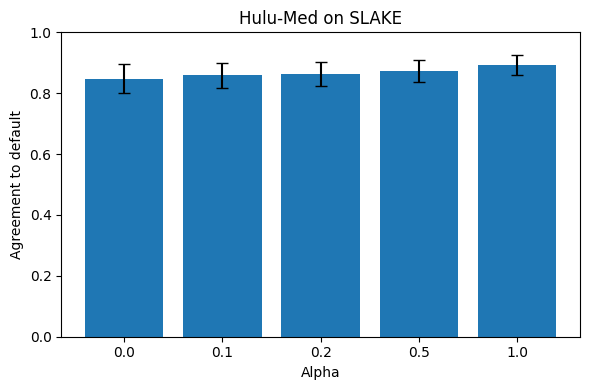

In [ ]:
import matplotlib.pyplot as plt

plot_df = (
    agreement_to_default[agreement_to_default["emotion"] != "default"]
    .groupby(["model", "dataset", "alpha"])
    .agg(
        mean_agreement=("agreement_to_default", "mean"),
        std_agreement=("agreement_to_default", "std"),
    )
    .reset_index()
)

# ví dụ chọn 1 model + 1 dataset
sub = plot_df[(plot_df["model"] == "Hulu-Med") & (plot_df["dataset"] == "SLAKE")]

plt.figure(figsize=(6, 4))
plt.bar(sub["alpha"].astype(str), sub["mean_agreement"], yerr=sub["std_agreement"], capsize=4)
plt.ylim(0, 1)
plt.xlabel("Alpha")
plt.ylabel("Agreement to default")
plt.title("Hulu-Med on SLAKE")
plt.tight_layout()
plt.show()

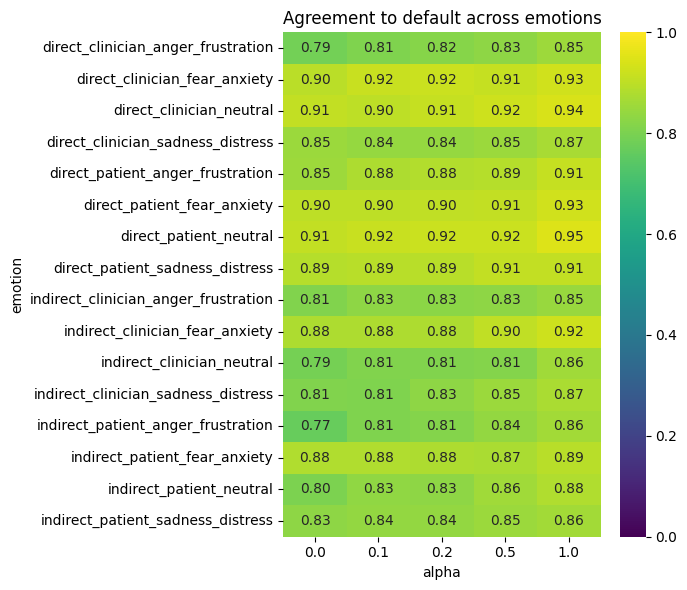

In [59]:
import seaborn as sns

sub = agreement_to_default[
    (agreement_to_default["model"] == "Hulu-Med") &
    (agreement_to_default["dataset"] == "SLAKE") &
    (agreement_to_default["emotion"] != "default")
]

heat_df = sub.pivot(index="emotion", columns="alpha", values="agreement_to_default")

plt.figure(figsize=(7, 6))
sns.heatmap(heat_df, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis")
plt.title("Agreement to default across emotions")
plt.tight_layout()
plt.show()

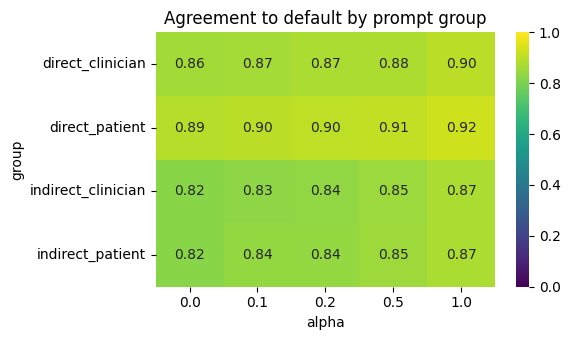

In [61]:
sub = agreement_to_default[
    (agreement_to_default["model"] == "Hulu-Med") &
    (agreement_to_default["dataset"] == "SLAKE") &
    (agreement_to_default["emotion"] != "default")
].copy()

def to_group(emotion):
    parts = emotion.split("_")
    return f"{parts[0]}_{parts[1]}"   # direct_clinician, direct_patient, ...

sub["group"] = sub["emotion"].apply(to_group)

heat_df = (
    sub.groupby(["group", "alpha"])["agreement_to_default"]
    .mean()
    .reset_index()
    .pivot(index="group", columns="alpha", values="agreement_to_default")
)

plt.figure(figsize=(6, 3.5))
sns.heatmap(heat_df, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis")
plt.title("Agreement to default by prompt group")
plt.tight_layout()
plt.show()

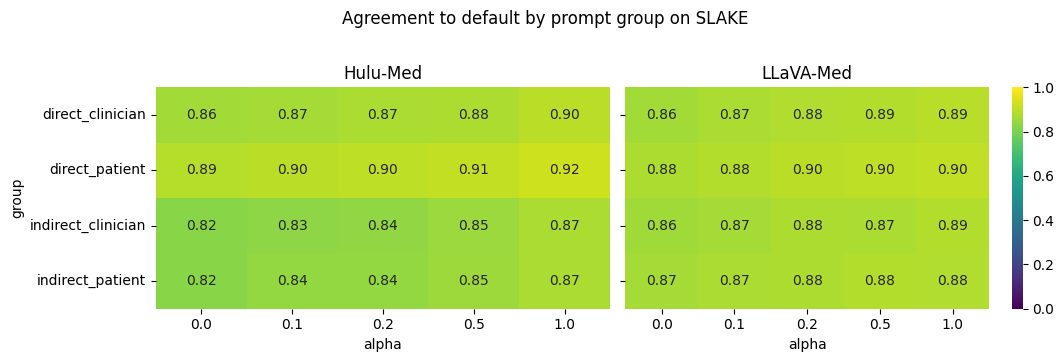

In [69]:
models_to_plot = ["Hulu-Med", "LLaVA-Med"]
dataset_name = "SLAKE"

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

for ax, model_name in zip(axes, models_to_plot):
    sub = agreement_to_default[
        (agreement_to_default["model"] == model_name) &
        (agreement_to_default["dataset"] == dataset_name) &
        (agreement_to_default["emotion"] != "default")
    ].copy()

    def to_group(emotion):
        parts = emotion.split("_")
        return f"{parts[0]}_{parts[1]}"

    sub["group"] = sub["emotion"].apply(to_group)

    heat_df = (
        sub.groupby(["group", "alpha"])["agreement_to_default"]
        .mean()
        .reset_index()
        .pivot(index="group", columns="alpha", values="agreement_to_default")
    )

    sns.heatmap(
        heat_df,
        annot=True,
        fmt=".2f",
        vmin=0,
        vmax=1,
        cmap="viridis",
        ax=ax,
        cbar=(model_name == "LLaVA-Med")
    )
    ax.set_title(model_name)
    ax.set_xlabel("alpha")

axes[0].set_ylabel("group")
axes[1].set_ylabel("")
plt.suptitle(f"Agreement to default by prompt group on {dataset_name}", y=1.02)
plt.tight_layout()
plt.show()

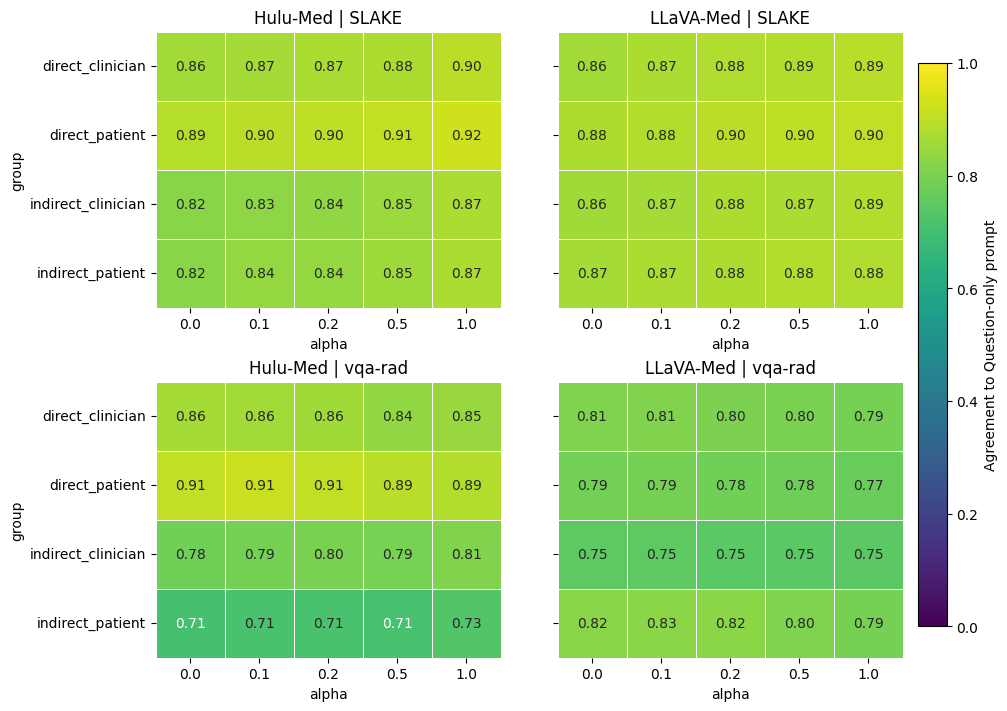

In [74]:
models_to_plot = ["Hulu-Med", "LLaVA-Med"]
datasets_to_plot = ["SLAKE", "vqa-rad"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

last_mappable = None

for i, dataset_name in enumerate(datasets_to_plot):
    for j, model_name in enumerate(models_to_plot):
        ax = axes[i, j]

        sub = agreement_to_default[
            (agreement_to_default["model"] == model_name) &
            (agreement_to_default["dataset"] == dataset_name) &
            (agreement_to_default["emotion"] != "default")
        ].copy()

        def to_group(emotion):
            parts = emotion.split("_")
            return f"{parts[0]}_{parts[1]}"

        sub["group"] = sub["emotion"].apply(to_group)

        heat_df = (
            sub.groupby(["group", "alpha"])["agreement_to_default"]
            .mean()
            .reset_index()
            .pivot(index="group", columns="alpha", values="agreement_to_default")
            .loc[["direct_clinician", "direct_patient", "indirect_clinician", "indirect_patient"]]
        )

        hm = sns.heatmap(
            heat_df,
            annot=True,
            fmt=".2f",
            vmin=0,
            vmax=1,
            cmap="viridis",
            ax=ax,
            cbar=False,
            square=True,
            linewidths=0.5,
            linecolor="white"
        )
        last_mappable = hm.collections[0]

        ax.set_title(f"{model_name} | {dataset_name}")
        ax.set_xlabel("alpha")
        if j == 0:
            ax.set_ylabel("group")
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

# 1 colorbar chung
cbar = fig.colorbar(last_mappable, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("Agreement to Question-only prompt")

plt.show()

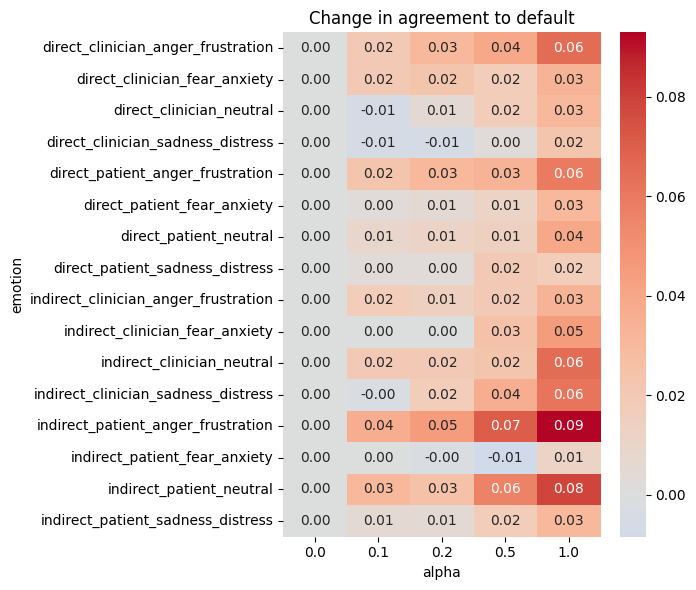

In [60]:
sub = agreement_to_default[
    (agreement_to_default["model"] == "Hulu-Med") &
    (agreement_to_default["dataset"] == "SLAKE") &
    (agreement_to_default["emotion"] != "default")
].copy()

base = sub[sub["alpha"] == 0][["emotion", "agreement_to_default"]].rename(
    columns={"agreement_to_default": "base_agreement"}
)

sub = sub.merge(base, on="emotion", how="left")
sub["delta_agreement"] = sub["agreement_to_default"] - sub["base_agreement"]

heat_df = sub.pivot(index="emotion", columns="alpha", values="delta_agreement")

plt.figure(figsize=(7, 6))
sns.heatmap(heat_df, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Change in agreement to default")
plt.tight_layout()
plt.show()